# O Perceptron e a Intuição da Linearidade

Neste caderno, vamos visualizar o funcionamento de um Perceptron simples operando como um classificador linear para as portas lógicas fundamentais (**AND** e **OR**). Além disso, demonstraremos a clássica limitação apontada por Minsky e Papert (1969): a incapacidade de um único Perceptron resolver problemas linearmente inseparáveis, como a porta **XOR** (Ou Exclusivo).

Desta vez, em vez de desenharmos a reta manualmente, vamos **treinar um Perceptron real** utilizando o `scikit-learn` para observar a região de decisão aprendida pelo modelo.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.linear_model import Perceptron
from matplotlib.colors import ListedColormap

# Fixando a semente para garantir a replicabilidade do treinamento e da inicialização dos pesos
np.random.seed(28)

# --- CONFIGURAÇÕES DE IDENTIDADE VISUAL (PALETA GRAN) ---
COR_AZUL_PRINCIPAL = "#0D134C"
COR_VERMELHO = "#DD303E"
COR_PRETO = "#000000"
COR_BRANCO = "#FFFFFF"
FUNDO_EIXOS = "#F9F9F9"

# Configurações de Tipografia (Otimizado para PDF)
FONT_LABEL = 20
FONT_TICK = 18
FONT_SUBFIGURE = 24

# Definição do tema Seaborn
sns.set_theme(style="whitegrid", rc={"axes.facecolor": FUNDO_EIXOS})

# Configuração de Fontes e Renderização de Glifos
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

## Treinamento e Limites de Decisão nas Portas Lógicas

Vamos instanciar o modelo `Perceptron` e treiná-lo nas três portas lógicas lado a lado. 

Para evidenciar o aprendizado, vamos colorir o fundo do gráfico indicando a região de decisão. Toda a plotagem (tanto a linha divisória quanto as cores de fundo) é gerada estritamente a partir da equação do hiperplano: $w_1x_1 + w_2x_2 + b = 0$. 

Repare com atenção no gráfico do **XOR**: como o problema não é linearmente separável, o Perceptron tentará traçar uma reta, mas ela dividirá o espaço de forma incorreta.

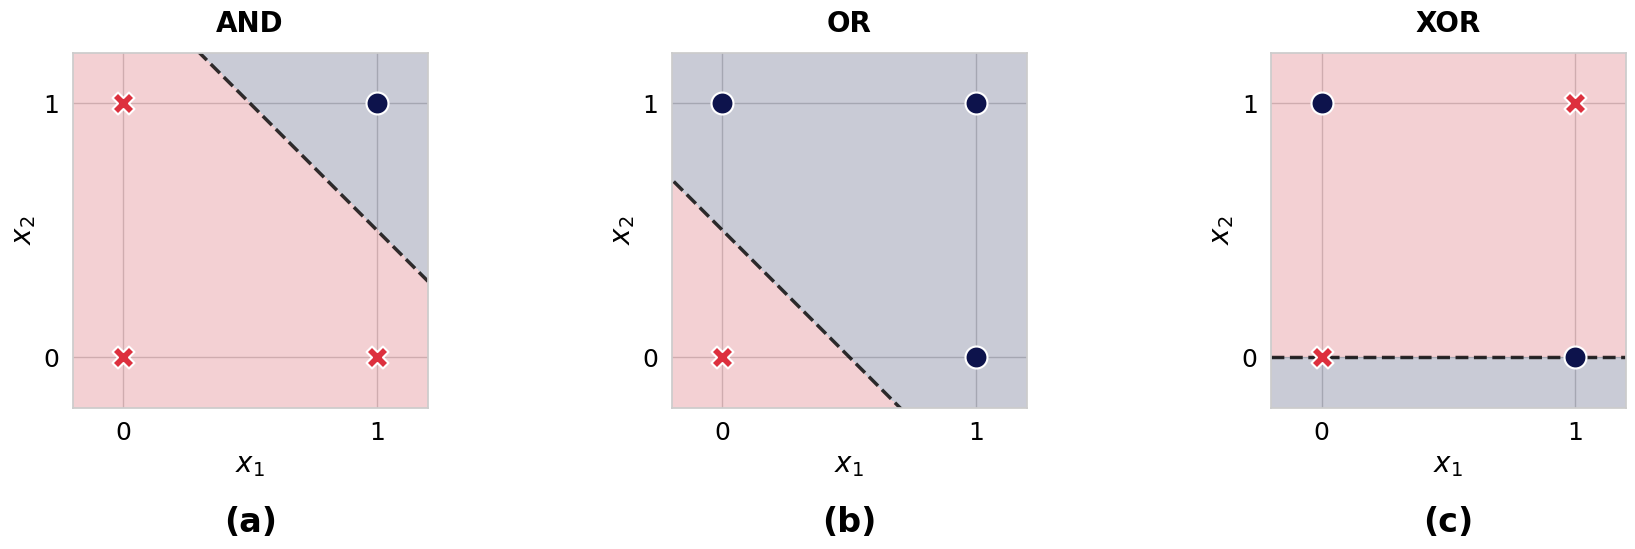

In [4]:
# Dados das entradas (x1, x2) para as portas lógicas
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])

# Saídas (Labels)
y_and = np.array([0, 0, 0, 1])
y_or  = np.array([0, 1, 1, 1])
y_xor = np.array([0, 1, 1, 0])

# Configuração da figura com 3 subplots lado a lado
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

eixos = [ax1, ax2, ax3]
labels = [y_and, y_or, y_xor]
titulos = ['AND', 'OR', 'XOR']
subtitulos = ['(a)', '(b)', '(c)']

mesh_res = 200

# Criando um grid para varrer todo o plano cartesiano
xx, yy = np.meshgrid(np.linspace(-0.2, 1.2, mesh_res), np.linspace(-0.2, 1.2, mesh_res))

# Colormap para o fundo
cmap_fundo = ListedColormap([COR_VERMELHO, COR_AZUL_PRINCIPAL])

for ax, y, titulo, subtitulo in zip(eixos, labels, titulos, subtitulos):
    
    # Instanciando o Perceptron. 
    # Para o XOR, usamos max_iter=4 para ilustrar uma reta falha antes que os pesos zerem.
    limite_iter = 1000
    clf = Perceptron(random_state=1, max_iter=limite_iter, tol=None)
    clf.fit(X, y)

    # 1. Extraindo os pesos diretamente do modelo
    w1, w2 = clf.coef_[0]
    b = clf.intercept_[0]
    
    # 2. Calculando as previsões do fundo ESTRITAMENTE com base em w1, w2 e b
    # Equação linear: z = w1*x1 + w2*x2 + b
    Z_linear = w1 * xx.ravel() + w2 * yy.ravel() + b
    
    # Função de Ativação Degrau (Step): Se >= 0 é Classe 1, senão Classe 0
    Z_ativado = np.where(Z_linear >= 0, 1, 0).reshape(xx.shape)
    
    # Pintando a região de decisão matematicamente calculada (opacidade 0.2)
    # ax.contourf(xx, yy, Z_ativado, alpha=0.2, cmap=cmap_fundo)
    ax.pcolormesh(xx, yy, Z_ativado, cmap=cmap_fundo, alpha=0.2, shading='auto', zorder=1)
    
    # 3. Desenhando a reta algebricamente com mapeamento completo de Edge Cases
    if w1 == 0 and w2 == 0:
        pass # Colapso total dos pesos: não há reta no espaço
    elif w1 == 0 and w2 != 0:
        # Reta perfeitamente horizontal
        ax.axhline(-b / w2, color=COR_PRETO, linestyle='--', linewidth=2.5, alpha=0.8, zorder=2)
    elif w2 == 0 and w1 != 0:
        # Reta perfeitamente vertical
        ax.axvline(-b / w1, color=COR_PRETO, linestyle='--', linewidth=2.5, alpha=0.8, zorder=2)
    else:
        # Reta diagonal padrão
        x_reta = np.linspace(-0.5, 1.5, 100) # Ampliado para cobrir melhor as diagonais
        y_reta = -(w1 / w2) * x_reta - (b / w2)
        ax.plot(x_reta, y_reta, color=COR_PRETO, linestyle='--', linewidth=2.5, alpha=0.8, zorder=2)

    # 4. Plotagem dos pontos reais
    for i in range(len(y)):
        cor = COR_AZUL_PRINCIPAL if y[i] == 1 else COR_VERMELHO
        marcador = 'o' if y[i] == 1 else 'X'
        ax.scatter(X[i, 0], X[i, 1], color=cor, s=250, marker=marcador, 
                   edgecolor=COR_BRANCO, linewidth=1.5, zorder=3)

    # --- REGRAS DE DIAGRAMAÇÃO E TIPOGRAFIA (GRAN) ---
    ax.set_title(titulo, fontsize=FONT_LABEL, fontweight='bold', color=COR_PRETO, pad=15)
    ax.set_xlim(-0.2, 1.2)
    ax.set_ylim(-0.2, 1.2)
    ax.set_box_aspect(1)
    
    ax.set_xlabel(r'$x_1$', fontsize=FONT_LABEL, color=COR_PRETO)
    ax.set_ylabel(r'$x_2$', fontsize=FONT_LABEL, color=COR_PRETO)
    ax.tick_params(axis='both', labelsize=FONT_TICK, colors=COR_PRETO)
    
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    
    ax.text(0.5, -0.35, subtitulo, transform=ax.transAxes, ha='center', 
            fontweight='bold', fontsize=FONT_SUBFIGURE, color=COR_PRETO)

plt.tight_layout(w_pad=2.0)
fig.subplots_adjust(bottom=0.35)

caminho_save = os.path.join('..', 'outputs', 'figures', 'aula_06')
os.makedirs(caminho_save, exist_ok=True)
plt.savefig(os.path.join(caminho_save, '01_perceptron_portas_logicas_treinado.png'), 
            dpi=300, bbox_inches='tight', pad_inches=0.4)

plt.show()

### Análise do Resultado
Observe como o treinamento resultou em sucesso para as portas **(a) AND** e **(b) OR**, onde o modelo traçou um plano de decisão (evidenciado pela pintura de fundo) que separa perfeitamente a área vermelha da azul. No entanto, o gráfico **(c) XOR** exibe uma falha categórica: o `Perceptron` tentou ajustar uma reta, mas dividiu incorretamente o espaço, pois a distribuição cruzada não é linearmente separável.

Essa visualização gerada a partir do comportamento empírico do algoritmo fundamenta matematicamente a necessidade de utilizarmos *Multi-Layer Perceptrons* (MLPs) para problemas complexos!